# 모델 A — ResNet50V2 학습 (담당: 태윤)

## 배경
- 기획 변경: 유사 페어 삭제 → 독버섯 7종 다중분류 (환자 대응용)
- 데이터: 7클래스, 총 1,781장 (클래스당 202~365장, 불균형비 1.81배)
- EDA 결과 혼동 위험 쌍:
  - entoloma_rhodopolium ↔ omphalotus_japonicus (색상 유사도 0.873, 최우선 확인 대상)
  - entoloma_rhodopolium ↔ amanita_pantherina (0.869)
  - amanita_virosa: 밝기가 예상보다 낮음 → 배경 영향 의심, Grad-CAM으로 검증 필요

## 작업 순서
1. 베이스라인 학습 (base freeze)
2. Fine-tuning (상위 30% unfreeze)
3. 테스트셋 평가 + Confusion Matrix
4. Grad-CAM (혼동 위험 클래스 우선)

## 필수 반영 사항
- `class_weight` 적용 필수 (클래스 불균형 보정)
- 팀원2(EfficientNetB0)와 **동일한 train/val/test split** 사용 (공정 비교를 위해 SEED 고정값 공유받을 것)

---

## Cell 1 — 환경 설정

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/data/PoisonMushroom'

CLASS_NAMES = [
    'amanita_pantherina',
    'amanita_subjunquillea',
    'entoloma_rhodopolium',
    'omphalotus_japonicus',
    'hypholoma_fasciculare',
    'amanita_virosa',
    'trichoderma_cornudamae',
]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42  # 팀원2와 반드시 동일한 값 사용

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — 데이터 파이프라인

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 1781 files belonging to 7 classes.
Using 1247 files for training.
Found 1781 files belonging to 7 classes.
Using 534 files for validation.
Train batches: 39
Val batches: 9
Test batches: 8


## Cell 3 — class_weight 계산

In [4]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = []
for images, labels in train_ds.unbatch():
    y_train_labels.append(np.argmax(labels.numpy()))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=np.array(y_train_labels)
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("적용할 class_weight:")
for cls, idx in zip(CLASS_NAMES, range(NUM_CLASSES)):
    print(f"  {cls}: {class_weight_dict[idx]:.3f}")

적용할 class_weight:
  amanita_pantherina: 1.142
  amanita_subjunquillea: 1.180
  entoloma_rhodopolium: 1.080
  omphalotus_japonicus: 1.086
  hypholoma_fasciculare: 0.995
  amanita_virosa: 0.704
  trichoderma_cornudamae: 0.995


## Cell 4 — 모델 구조 (ResNet50V2)

In [5]:
def build_resnet50v2(num_classes, img_size=(224, 224)):
    base_model = ResNet50V2(
        input_shape=img_size + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=img_size + (3,))
    x = data_augmentation(inputs)
    x = tf.keras.applications.resnet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model

model_a, base_a = build_resnet50v2(NUM_CLASSES)
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_a.summary()
model_a.count_params()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,579,143 (89.95 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

23579143

## Cell 5 — 1단계: 베이스라인 학습

In [6]:
'''
os.makedirs('/content/drive/MyDrive/PoisonMushroom/models', exist_ok=True)

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/PoisonMushroom/models/model_a_stage1.keras',
        monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    )
]

history_a_stage1 = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1
)
'''

"\nos.makedirs('/content/drive/MyDrive/PoisonMushroom/models', exist_ok=True)\n\ncallbacks_stage1 = [\n    tf.keras.callbacks.EarlyStopping(\n        monitor='val_loss', patience=5, restore_best_weights=True\n    ),\n    tf.keras.callbacks.ModelCheckpoint(\n        '/content/drive/MyDrive/PoisonMushroom/models/model_a_stage1.keras',\n        monitor='val_accuracy', save_best_only=True\n    ),\n    tf.keras.callbacks.ReduceLROnPlateau(\n        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6\n    )\n]\n\nhistory_a_stage1 = model_a.fit(\n    train_ds,\n    validation_data=val_ds,\n    epochs=20,\n    class_weight=class_weight_dict,\n    callbacks=callbacks_stage1\n)\n"

# Cell 5-2 베스트 모델 이어서 학습

In [7]:
model_a = tf.keras.models.load_model(
    '/content/drive/MyDrive/Colab Notebooks/DL/독버섯_프로젝트/modelA/model_a.keras'
)

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/PoisonMushroom/models/model_a_2.keras',
        monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    )
]


# EarlyStopping이 알아서 val_loss 안 좋아지면 멈춰줌
history_a_stage1_resumed = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # 추가로 더 돌릴 epoch 수
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9447 - loss: 0.1804 - val_accuracy: 0.9065 - val_loss: 0.3163 - learning_rate: 5.0000e-04
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9350 - loss: 0.1984 - val_accuracy: 0.9065 - val_loss: 0.3108 - learning_rate: 5.0000e-04
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.9479 - loss: 0.1692 - val_accuracy: 0.9101 - val_loss: 0.3116 - learning_rate: 5.0000e-04
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9479 - loss: 0.1605 - val_accuracy: 0.9065 - val_loss: 0.3175 - learning_rate: 5.0000e-04
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - accuracy: 0.9655 - loss: 0.1380 - val_accuracy: 0.8993 - val_loss: 0.3063 - learning_rate: 5.0000e-04
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - accuracy: 0.9519 - loss: 0.1647 - val_accuracy: 0.8993 - val_loss: 0.3148 - learning_rate: 5.0000e-04
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0

## Cell 6 — 1단계 학습 곡선

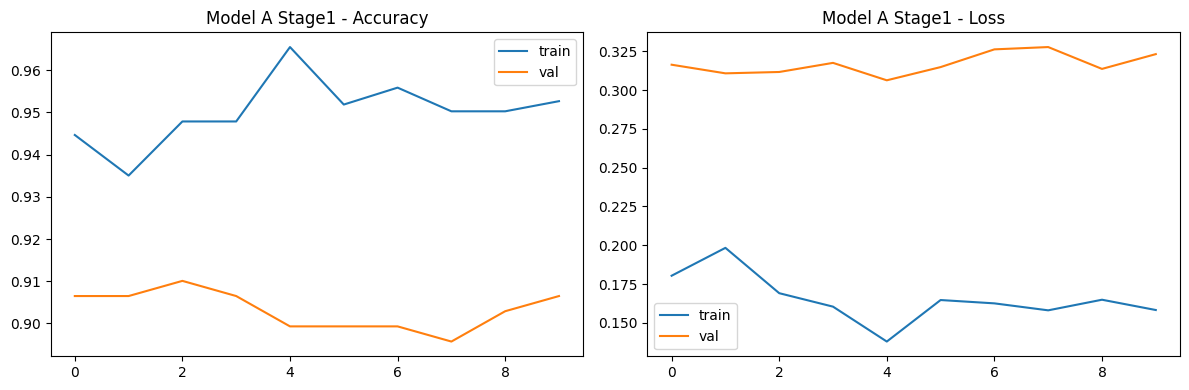

Stage1 최고 val_accuracy: 0.9100719690322876


In [8]:
history_a_stage1= history_a_stage1_resumed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_a_stage1.history['accuracy'], label='train')
axes[0].plot(history_a_stage1.history['val_accuracy'], label='val')
axes[0].set_title('Model A Stage1 - Accuracy')
axes[0].legend()

axes[1].plot(history_a_stage1.history['loss'], label='train')
axes[1].plot(history_a_stage1.history['val_loss'], label='val')
axes[1].set_title('Model A Stage1 - Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Stage1 최고 val_accuracy:", max(history_a_stage1.history['val_accuracy']))

## Cell 7 — 2단계: Fine-tuning 준비

In [9]:
model_a = tf.keras.models.load_model(
    '/content/drive/MyDrive/PoisonMushroom/models/model_a_2.keras'
)

# model_a.summary() 로 base_model 위치(인덱스) 먼저 확인할 것
# 인덱스 대신 이름으로 찾기 (구조가 바뀌어도 안전)
base_a = model_a.get_layer('resnet50v2')
base_a.trainable = True

total_layers = len(base_a.layers)
fine_tune_at = int(total_layers * 0.7)

for layer in base_a.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_a.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(f"전체 레이어: {total_layers}, Fine-tune 시작 지점: {fine_tune_at}")
print(f"학습 가능 레이어 수: {sum([l.trainable for l in base_a.layers])}")

model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

전체 레이어: 190, Fine-tune 시작 지점: 133
학습 가능 레이어 수: 42


## Cell 8 — 2단계: Fine-tuning 학습

In [10]:
callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/PoisonMushroom/models/model_a_finetuned.keras',
        monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
    )
]

initial_epoch = len(history_a_stage1.history['loss'])

history_a_stage2 = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epoch + 15,
    initial_epoch=initial_epoch,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2
)

Epoch 11/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 34s 592ms/step - accuracy: 0.9431 - loss: 0.1667 - val_accuracy: 0.9137 - val_loss: 0.2767 - learning_rate: 1.0000e-05
Epoch 12/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.9503 - loss: 0.1517 - val_accuracy: 0.9209 - val_loss: 0.2815 - learning_rate: 1.0000e-05
Epoch 13/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.9663 - loss: 0.1052 - val_accuracy: 0.9137 - val_loss: 0.2667 - learning_rate: 1.0000e-05
Epoch 14/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - accuracy: 0.9703 - loss: 0.0849 - val_accuracy: 0.9173 - val_loss: 0.2653 - learning_rate: 1.0000e-05
Epoch 15/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 235ms/step - accuracy: 0.9791 - loss: 0.0645 - val_accuracy: 0.9173 - val_loss: 0.2727 - learning_rate: 1.0000e-05
Epoch 16/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 321ms/step - accuracy: 0.9759 - loss: 0.0841 - val_accuracy: 0.9317 - val_loss: 0.2547 - learning_rate: 1.0000e-05
Epoch 17/25
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step 

## Cell 9 — 전체 학습 곡선

In [ ]:
# 1. 나눔고딕 폰트 설치
!apt-get -qq install fonts-nanum
!fc-cache -fv

# 2. matplotlib에 폰트 등록
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

/tmp/ipykernel_704/1199247810.py:19: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_704/1199247810.py:19: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_704/1199247810.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_704/1199247810.py:19: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-

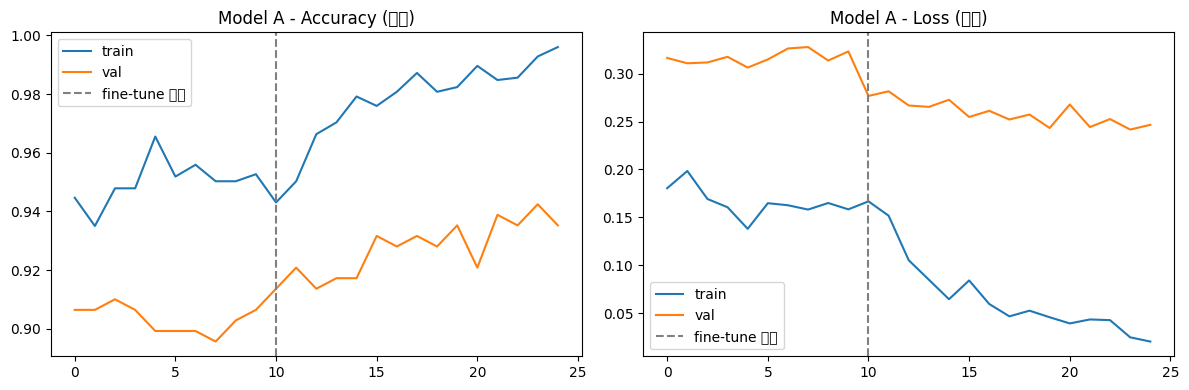

최종 최고 val_accuracy: 0.9424460530281067


In [11]:


acc = history_a_stage1.history['accuracy'] + history_a_stage2.history['accuracy']
val_acc = history_a_stage1.history['val_accuracy'] + history_a_stage2.history['val_accuracy']
loss = history_a_stage1.history['loss'] + history_a_stage2.history['loss']
val_loss = history_a_stage1.history['val_loss'] + history_a_stage2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(acc, label='train')
axes[0].plot(val_acc, label='val')
axes[0].axvline(initial_epoch, color='gray', linestyle='--', label='fine-tune 시작')
axes[0].set_title('Model A - Accuracy (전체)')
axes[0].legend()

axes[1].plot(loss, label='train')
axes[1].plot(val_loss, label='val')
axes[1].axvline(initial_epoch, color='gray', linestyle='--', label='fine-tune 시작')
axes[1].set_title('Model A - Loss (전체)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("최종 최고 val_accuracy:", max(val_acc))

## Cell 10 — 테스트셋 평가 + Confusion Matrix

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 746ms/step - accuracy: 0.9180 - loss: 0.2874
Test Accuracy: 0.9180, Test Loss: 0.2874

분류 리포트:
                        precision    recall  f1-score   support

    amanita_pantherina       0.82      0.97      0.89        29
 amanita_subjunquillea       0.86      0.83      0.84        23
  entoloma_rhodopolium       0.92      0.77      0.84        31
  omphalotus_japonicus       0.91      0.95      0.93        42
 hypholoma_fasciculare       0.90      0.90      0.90        31
        amanita_virosa       0.96      0.96      0.96        56
trichoderma_cornudamae       0.98      0.95      0.97        44

              accuracy                           0.92       256
             macro avg       0.91      0.91      0.91       256
          weighted avg       0.92      0.92      0.92       256



/tmp/ipykernel_704/3301583777.py:24: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_704/3301583777.py:24: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_704/3301583777.py:24: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_704/3301583777.py:24: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-p

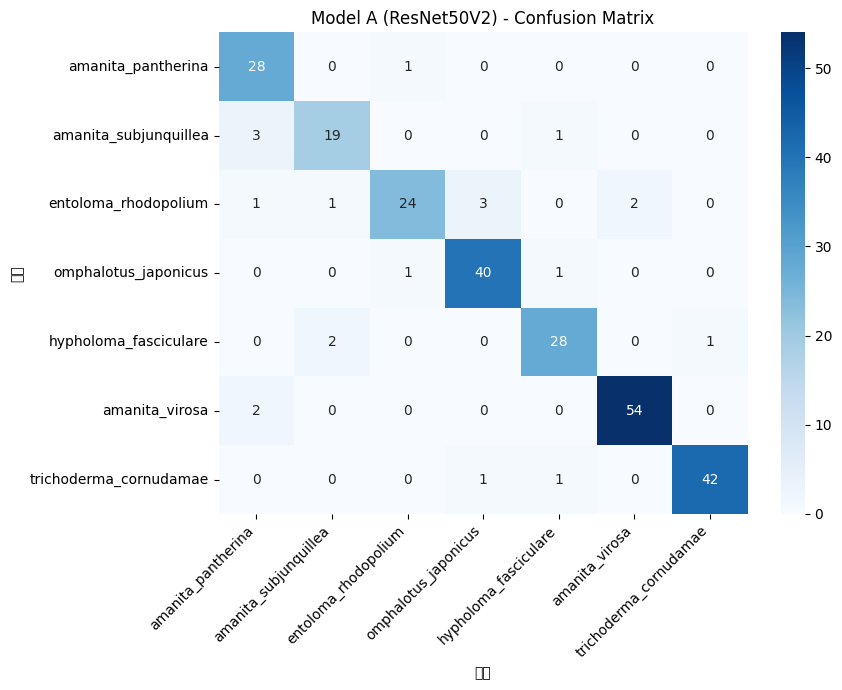

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = model_a.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model_a.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\n분류 리포트:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Model A (ResNet50V2) - Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import classification_report

report_a = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

import json
with open('/content/drive/MyDrive/PoisonMushroom/report_a.json', 'w') as f:
    json.dump(report_a, f)

---

## 검증 체크리스트
- [ ] class_weight 적용 확인
- [ ] entoloma_rhodopolium ↔ omphalotus_japonicus 실제 confusion matrix에서 혼동되는지 확인
- [ ] amanita_virosa recall 확인 (배경 영향 의심 → Grad-CAM으로 실제 버섯에 집중하는지 검증)
- [ ] 소수 클래스(amanita_subjunquillea, amanita_pantherina) recall 확인
- [ ] 학습된 모델(.keras), 학습곡선, confusion matrix,  이미지 팀장에게 전달